# 12 — Real option-data acquisition and preparation

This stage prepares a real option-chain snapshot for calibration.

## Data source

The preferred source is the official **Cboe Option EOD Summary sample**. It
contains OPRA-derived option series with:

- strike and expiration;
- call/put type;
- 15:45 U.S. Eastern NBBO bid, ask and sizes;
- end-of-day NBBO;
- trade volume and open interest;
- underlying quotes for stocks and ETFs when available.

We use the **15:45 snapshot** because Cboe identifies it as a better
representation of market liquidity than the final end-of-day snapshot.

The repository includes the official DataShop sample ZIP for reproducible
offline execution. If it is absent, the notebook downloads it directly; it
does not scrape Cboe's delayed-quote webpage.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.cboe_market_data import (
    PreparationSettings,
    available_symbols,
    choose_preferred_symbol,
    download_cboe_eod_sample,
    load_cboe_sample_zip,
    prepare_cboe_sample_dataset,
)


## 1. Download and inspect the official sample

The bundled sample ZIP is reused locally. It is downloaded only when missing.

If Cboe changes the sample-download identifier, visit the Option EOD Summary
product page, download its sample manually, and place the ZIP at the path shown
below.


In [3]:
raw_directory = (
    project_root
    / "data"
    / "market"
    / "raw"
)
raw_directory.mkdir(
    parents=True,
    exist_ok=True,
)

sample_zip_path = (
    raw_directory
    / "cboe_option_eod_sample.zip"
)

if sample_zip_path.exists():
    print("Using bundled Cboe sample:", sample_zip_path)
else:
    print("Downloading official Cboe sample...")
    download_cboe_eod_sample(sample_zip_path)

raw_options = load_cboe_sample_zip(
    sample_zip_path
)

print("Raw rows:", len(raw_options))
print("Columns:", raw_options.columns.tolist())
raw_options.head()


Using bundled Cboe sample: /mnt/data/dupire_audit/dupire_local_vol_project/data/market/raw/cboe_option_eod_sample.zip


Raw rows: 65344
Columns: ['underlying_symbol', 'quote_date', 'root', 'expiration', 'strike', 'option_type', 'open', 'high', 'low', 'close', 'trade_volume', 'bid_size_1545', 'bid_1545', 'ask_size_1545', 'ask_1545', 'underlying_bid_1545', 'underlying_ask_1545', 'implied_underlying_price_1545', 'active_underlying_price_1545', 'implied_volatility_1545', 'delta_1545', 'gamma_1545', 'theta_1545', 'vega_1545', 'rho_1545', 'bid_size_eod', 'bid_eod', 'ask_size_eod', 'ask_eod', 'underlying_bid_eod', 'underlying_ask_eod', 'vwap', 'open_interest', 'delivery_code', 'source_file']


,underlying_symbol,quote_date,root,expiration,strike,option_type,open,high,low,close,trade_volume,bid_size_1545,bid_1545,ask_size_1545,ask_1545,underlying_bid_1545,underlying_ask_1545,implied_underlying_price_1545,active_underlying_price_1545,implied_volatility_1545,delta_1545,gamma_1545,theta_1545,vega_1545,rho_1545,bid_size_eod,bid_eod,ask_size_eod,ask_eod,underlying_bid_eod,underlying_ask_eod,vwap,open_interest,delivery_code,source_file
0,SPY,2023-08-25,SPY,2023-08-25,275.0,C,163.68,163.68,163.17,163.17,9,10,165.7,10,165.85,440.78,440.8,0.0,440.79,0.0,0.0,0.0,0.0,0.0,0.0,1,164.66,37,165.23,440.04,440.07,163.5100,143,NaN,UnderlyingOptionsEODCalcs_2023-08-25_no_cgi_su...
1,SPY,2023-08-25,SPY,2023-08-25,275.0,P,0.00,0.00,0.00,0.00,0,0,0.0,6847,0.01,440.78,440.8,0.0,440.79,0.0,0.0,0.0,0.0,0.0,0.0,0,0.00,307,0.01,440.04,440.07,0.0000,3414,NaN,UnderlyingOptionsEODCalcs_2023-08-25_no_cgi_su...
2,SPY,2023-08-25,SPY,2023-08-25,280.0,C,158.73,158.73,157.45,158.33,5,10,160.7,10,160.85,440.78,440.8,0.0,440.79,0.0,0.0,0.0,0.0,0.0,0.0,1,159.66,37,160.23,440.04,440.07,158.2340,86,NaN,UnderlyingOptionsEODCalcs_2023-08-25_no_cgi_su...
3,SPY,2023-08-25,SPY,2023-08-25,280.0,P,0.00,0.00,0.00,0.00,0,0,0.0,6809,0.01,440.78,440.8,0.0,440.79,0.0,0.0,0.0,0.0,0.0,0.0,0,0.00,102,0.01,440.04,440.07,0.0000,1342,NaN,UnderlyingOptionsEODCalcs_2023-08-25_no_cgi_su...
4,SPY,2023-08-25,SPY,2023-08-25,285.0,C,153.73,153.73,152.06,152.06,3,10,155.7,10,155.84,440.78,440.8,0.0,440.79,0.0,0.0,0.0,0.0,0.0,0.0,1,154.66,37,155.24,440.04,440.07,152.7467,67,NaN,UnderlyingOptionsEODCalcs_2023-08-25_no_cgi_su...


## 2. Choose one underlying and date

The preferred order is:

1. SPX;
2. XSP;
3. SPY;
4. otherwise, the symbol/date with the largest number of matched call-put
   strikes.

SPX and XSP are especially suitable because their index options are European
style. Equity and ETF options may be American style, in which case put-call
parity and the European Dupire model are approximations.


In [4]:
symbol_summary = available_symbols(
    raw_options
)

symbol_summary.head(20)


,underlying_symbol,quote_date,number_of_series,number_of_expirations,matched_call_put_strikes
0,^SPX,2023-08-25,16394,50,8197
1,SPY,2023-08-25,7630,29,3815
2,TSLA,2023-08-25,4238,19,2119
3,^VIX,2023-08-25,1438,13,719


In [5]:
selected_symbol, selected_date = (
    choose_preferred_symbol(
        raw_options
    )
)

print("Selected symbol:", selected_symbol)
print("Selected quote date:", selected_date.date())


Selected symbol: ^SPX
Selected quote date: 2023-08-25


## 3. Quality filters and forward inference

We retain quotes with:

- non-crossed positive bid/ask markets;
- relative spread no greater than \(50\%\);
- maturity between 14 days and two years;
- absolute forward log-moneyness no greater than \(0.35\).

For each expiry, matched calls and puts are used to fit:

$$
C(K,T)-P(K,T)
=
A(T)-D(T)K.
$$

Then:

$$
F(T)=\frac{A(T)}{D(T)}
$$

and

$$
r(T)=-\frac{\log D(T)}{T}.
$$

A robust weighted fit is used so that wide quotes have less influence.


In [6]:
settings = PreparationSettings(
    snapshot="1545",
    minimum_days_to_expiry=14,
    maximum_days_to_expiry=730,
    maximum_relative_spread=0.50,
    maximum_absolute_log_moneyness=0.35,
    minimum_noise_standard_deviation=0.01,
    minimum_parity_pairs=5,
    test_fraction=0.20,
)

stage_12_result = prepare_cboe_sample_dataset(
    raw_data=raw_options,
    symbol=selected_symbol,
    quote_date=selected_date,
    settings=settings,
)

forward_curve = stage_12_result[
    "forward_curve"
]
prepared_quotes = stage_12_result[
    "prepared_quotes"
]
arbitrage_diagnostics = stage_12_result[
    "arbitrage_diagnostics"
]
metadata = stage_12_result["metadata"]

metadata


{'symbol': '^SPX',
 'quote_date': '2023-08-25',
 'snapshot': '1545',
 'exercise_style': 'european_index',
 'number_of_raw_rows': 65344,
 'number_of_filtered_option_rows': 29618,
 'number_of_prepared_quotes': 5092,
 'number_of_train_quotes': 4071,
 'number_of_test_quotes': 1021,
 'number_of_expirations': 37}

In [7]:
forward_curve


,expiration,maturity,number_of_parity_pairs,prepaid_forward,discount_factor,forward,implied_rate,parity_rmse,parity_success
0,2023-09-08,0.038330,157,4409.911515,0.997654,4420.282150,0.061281,0.175270,True
1,2023-09-11,0.046543,146,4410.148780,0.997542,4421.014248,0.052869,0.169533,True
2,2023-09-12,0.049281,103,4410.104174,0.997401,4421.593783,0.052797,0.343454,True
3,2023-09-13,0.052019,108,4409.648771,0.997154,4422.235974,0.054795,0.263525,True
4,2023-09-14,0.054757,100,4409.529516,0.996950,4423.019175,0.055783,0.249164,True
5,2023-09-15,0.057495,281,4408.991062,0.996719,4423.505691,0.057164,0.269169,True
6,2023-09-18,0.065708,133,4408.540549,0.996463,4424.188170,0.053922,0.297470,True
7,2023-09-19,0.068446,93,4408.505044,0.996295,4424.899313,0.054231,0.175897,True
8,2023-09-20,0.071184,103,4408.135317,0.996071,4425.522578,0.055302,0.214442,True
9,2023-09-21,0.073922,81,4409.302193,0.995938,4427.286361,0.055063,0.149716,True


## 4. OTM-source construction

At each strike:

- use the call when \(K\geq F(T)\);
- use the put when \(K<F(T)\);
- convert the OTM put into a European call-equivalent price using put-call
  parity.

This avoids relying on illiquid deep in-the-money quotes.

The observed price is the bid-ask midpoint, and the quote-noise scale is:

$$
s_i
=
\max\left(
\frac{\text{ask}_i-\text{bid}_i}{2},
0.01
\right).
$$

The calibration weight is \(1/s_i\).


In [8]:
prepared_quotes[
    [
        "expiration",
        "maturity",
        "strike",
        "source_option",
        "observed_call_price",
        "noise_standard_deviation",
        "forward",
        "discount_factor",
        "log_moneyness",
        "is_train",
        "is_test",
    ]
].head(20)


,expiration,maturity,strike,source_option,observed_call_price,noise_standard_deviation,forward,discount_factor,log_moneyness,is_train,is_test
0,2023-09-08,0.03833,3300.0,otm_put_parity,1117.853802,0.050,4420.28215,0.997654,-0.292281,True,False
1,2023-09-08,0.03833,3400.0,otm_put_parity,1018.138417,0.050,4420.28215,0.997654,-0.262428,False,True
2,2023-09-08,0.03833,3450.0,otm_put_parity,968.305724,0.050,4420.28215,0.997654,-0.247829,True,False
3,2023-09-08,0.03833,3500.0,otm_put_parity,918.473032,0.050,4420.28215,0.997654,-0.233441,True,False
4,2023-09-08,0.03833,3550.0,otm_put_parity,868.640339,0.050,4420.28215,0.997654,-0.219256,True,False
5,2023-09-08,0.03833,3600.0,otm_put_parity,818.807647,0.050,4420.28215,0.997654,-0.205270,True,False
6,2023-09-08,0.03833,3650.0,otm_put_parity,768.974954,0.050,4420.28215,0.997654,-0.191476,False,True
7,2023-09-08,0.03833,3700.0,otm_put_parity,719.142261,0.050,4420.28215,0.997654,-0.177871,True,False
8,2023-09-08,0.03833,3750.0,otm_put_parity,669.359569,0.050,4420.28215,0.997654,-0.164448,True,False
9,2023-09-08,0.03833,3775.0,otm_put_parity,644.443222,0.025,4420.28215,0.997654,-0.157803,True,False


## 5. Inspect quote coverage

The black points are training quotes and the open points are held out for the
model comparison in Stage 13.


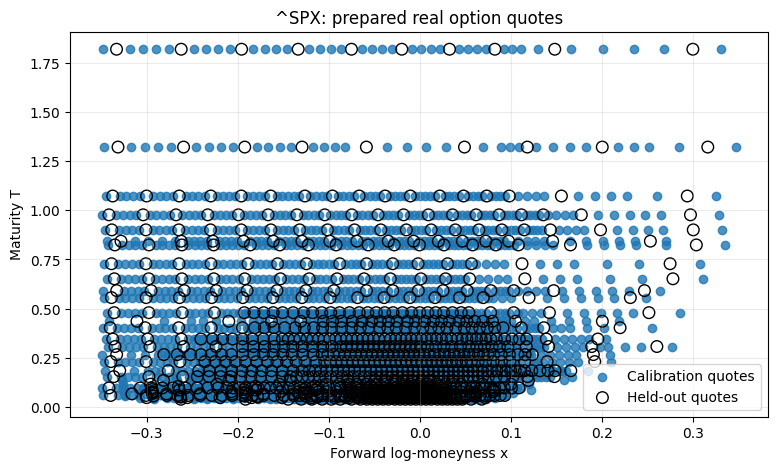

In [9]:
plt.figure(figsize=(9, 5.0))

train = prepared_quotes[
    prepared_quotes["is_train"]
]
test = prepared_quotes[
    prepared_quotes["is_test"]
]

plt.scatter(
    train["log_moneyness"],
    train["maturity"],
    label="Calibration quotes",
    alpha=0.8,
)
plt.scatter(
    test["log_moneyness"],
    test["maturity"],
    facecolors="none",
    edgecolors="black",
    s=70,
    label="Held-out quotes",
)

plt.xlabel("Forward log-moneyness x")
plt.ylabel("Maturity T")
plt.title(
    f"{selected_symbol}: prepared real option quotes"
)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. Static-arbitrage diagnostics

For each expiry we count:

- call-price increases as strike rises;
- violations of convexity across strike.

A small number of apparent violations can result from bid-ask noise. Stage 13
will fit an arbitrage-aware SSVI benchmark and compare its held-out performance
with the operator-regularised model.


In [10]:
arbitrage_diagnostics


,expiration,number_of_quotes,monotonicity_violations,convexity_violations
0,2023-09-08,157,0,0
1,2023-09-11,146,0,0
2,2023-09-12,103,0,0
3,2023-09-13,108,0,0
4,2023-09-14,100,0,0
5,2023-09-15,273,0,9
6,2023-09-18,132,0,0
7,2023-09-19,93,0,0
8,2023-09-20,102,0,0
9,2023-09-21,81,0,0


## 7. Save the prepared real-data snapshot

Only the processed research dataset is used by later stages. The official Cboe
sample ZIP remains in `data/market/raw` so Stage 12 can be reproduced offline.


In [11]:
processed_directory = (
    project_root
    / "data"
    / "market"
    / "processed"
)
processed_directory.mkdir(
    parents=True,
    exist_ok=True,
)

safe_symbol = (
    selected_symbol
    .replace("^", "")
    .replace("/", "_")
)
date_text = selected_date.strftime(
    "%Y-%m-%d"
)

prepared_path = (
    processed_directory
    / f"{safe_symbol}_{date_text}_prepared_quotes.csv"
)
forward_path = (
    processed_directory
    / f"{safe_symbol}_{date_text}_forward_curve.csv"
)
diagnostic_path = (
    processed_directory
    / f"{safe_symbol}_{date_text}_arbitrage_diagnostics.csv"
)
metadata_path = (
    processed_directory
    / f"{safe_symbol}_{date_text}_metadata.json"
)

prepared_quotes.to_csv(
    prepared_path,
    index=False,
)
forward_curve.to_csv(
    forward_path,
    index=False,
)
arbitrage_diagnostics.to_csv(
    diagnostic_path,
    index=False,
)
metadata_path.write_text(
    json.dumps(
        metadata,
        indent=2,
    ),
    encoding="utf-8",
)

print(prepared_path)
print(forward_path)
print(diagnostic_path)
print(metadata_path)


/mnt/data/dupire_audit/dupire_local_vol_project/data/market/processed/SPX_2023-08-25_prepared_quotes.csv
/mnt/data/dupire_audit/dupire_local_vol_project/data/market/processed/SPX_2023-08-25_forward_curve.csv
/mnt/data/dupire_audit/dupire_local_vol_project/data/market/processed/SPX_2023-08-25_arbitrage_diagnostics.csv
/mnt/data/dupire_audit/dupire_local_vol_project/data/market/processed/SPX_2023-08-25_metadata.json


## Stage 12 result

The real-market dataset now contains everything needed for calibration:

- one coherent quote date and underlying;
- bid, ask and midpoint prices;
- bid-ask-based observation uncertainty;
- maturity and forward log-moneyness;
- forward and discount factor by expiry;
- call-equivalent prices sourced from liquid OTM options;
- deterministic calibration and held-out sets;
- basic static-arbitrage diagnostics;
- a recorded European-versus-American exercise-style caveat.

Stage 13 will fit SSVI–Dupire and the operator-regularised inverse model using
the training quotes, then compare them on the held-out quotes.
